In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

# Reload data
df = pd.read_csv("urdu_emotions.csv")

# Label mapping
label2id = {"happy": 0, "sad": 1, "angry": 2, "fear": 3, "neutral": 4}
id2label = {v: k for k, v in label2id.items()}
df['label'] = df['emotion'].map(label2id)

# Split
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['label']
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

print("Everything reloaded!")
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

Everything reloaded!
Train: 36 | Test: 9


In [7]:
import torch
from torch.utils.data import Dataset

class UrduEmotionDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe['text'].tolist()
        self.labels = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Convert text to tokens
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = UrduEmotionDataset(train_df, tokenizer)
test_dataset = UrduEmotionDataset(test_df, tokenizer)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")

# Test one sample
sample = train_dataset[0]
print(f"\nSample input shape: {sample['input_ids'].shape}")
print(f"Sample label: {sample['label']} = {id2label[sample['label'].item()]}")

Train dataset: 36 samples
Test dataset:  9 samples

Sample input shape: torch.Size([128])
Sample label: 4 = neutral


In [8]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)
print("✅ Model ready!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model ready!


In [9]:
import subprocess
subprocess.run(["pip", "install", "accelerate>=1.1.0", "--upgrade"])
subprocess.run(["pip", "install", "transformers[torch]", "--upgrade"])
print("Done installing!")

Done installing!


In [12]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {
        "accuracy": round(float(accuracy), 4),
        "f1": round(float(f1), 4)
    }

training_args = TrainingArguments(
    output_dir="./urdu-emotion-model",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    metric_for_best_model="f1",
    logging_steps=10,
    warmup_steps=5,
    weight_decay=0.01,
    report_to="none",
    use_cpu=True
)

print(" Training settings ready!")

 Training settings ready!


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print(" Starting training...")
print("You will see logs after each epoch\n")

trainer.train()

print("\n Training complete!")

 Starting training...
You will see logs after each epoch



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.594532,0.222200,0.080800
2,1.544576,1.466134,0.444400,0.348100
3,1.587250,1.397639,0.444400,0.364000
4,1.348244,1.352575,0.666700,0.622200
5,1.274277,1.163816,0.888900,0.881500
6,0.917817,1.038415,0.666700,0.622200
7,0.771551,1.099972,0.777800,0.770400
8,0.659056,0.888448,0.888900,0.881500
9,0.449051,0.868720,0.777800,0.770400
10,0.378200,0.833972,0.777800,0.770400



 Training complete!


DETAILED RESULTS PER EMOTION
              precision    recall  f1-score   support

       happy       0.50      0.50      0.50         2
         sad       0.67      1.00      0.80         2
       angry       1.00      1.00      1.00         2
        fear       1.00      1.00      1.00         1
     neutral       1.00      0.50      0.67         2

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.79         9
weighted avg       0.81      0.78      0.77         9



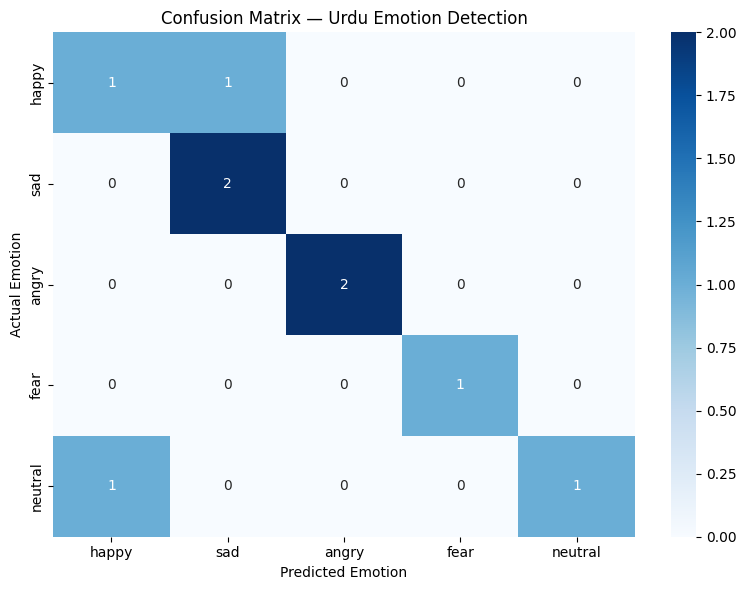

Confusion matrix saved!


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Print detailed results
emotion_names = ["happy", "sad", "angry", "fear", "neutral"]
print("=" * 50)
print("DETAILED RESULTS PER EMOTION")
print("=" * 50)
print(classification_report(
    true_labels,
    pred_labels,
    target_names=emotion_names
))

# Plot confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cmap='Blues'
)
plt.title("Confusion Matrix — Urdu Emotion Detection")
plt.ylabel("Actual Emotion")
plt.xlabel("Predicted Emotion")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print("Confusion matrix saved!")

In [21]:
import torch
import os

# Save to D: drive instead of C:
save_path = "D:/my-urdu-emotion-model"
os.makedirs(save_path, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), os.path.join(save_path, "model_weights.pt"))

# Save tokenizer and config
tokenizer.save_pretrained(save_path)
model.config.save_pretrained(save_path)

print(" Model saved to D: drive successfully!")
print(f"Location: {save_path}")

 Model saved to D: drive successfully!
Location: D:/my-urdu-emotion-model


In [22]:
import shutil
total, used, free = shutil.disk_usage("D:/")
print(f"D: drive - Total: {total // (2**30)} GB")
print(f"D: drive - Free:  {free // (2**30)} GB")

D: drive - Total: 88 GB
D: drive - Free:  86 GB


In [23]:
from transformers import pipeline

# Use model in memory to test
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

test_sentences = [
    "میں بہت خوش ہوں",
    "مجھے بہت دکھ ہوا",
    "مجھے بہت غصہ آ رہا ہے",
    "مجھے ڈر لگ رہا ہے",
    "آج معمول کا دن تھا"
]

print("Live Testing Your Model:")
print("=" * 40)
for sentence in test_sentences:
    result = classifier(sentence)[0]
    print(f"Text: {sentence}")
    print(f"Emotion: {result['label']} ({round(result['score']*100, 1)}% confident)")
    print("-" * 40)

Live Testing Your Model:
Text: میں بہت خوش ہوں
Emotion: happy (95.3% confident)
----------------------------------------
Text: مجھے بہت دکھ ہوا
Emotion: sad (77.2% confident)
----------------------------------------
Text: مجھے بہت غصہ آ رہا ہے
Emotion: angry (85.7% confident)
----------------------------------------
Text: مجھے ڈر لگ رہا ہے
Emotion: fear (64.4% confident)
----------------------------------------
Text: آج معمول کا دن تھا
Emotion: happy (89.1% confident)
----------------------------------------
